## Basic Andrews Curve (Pandas)
🔹 Best for a first look

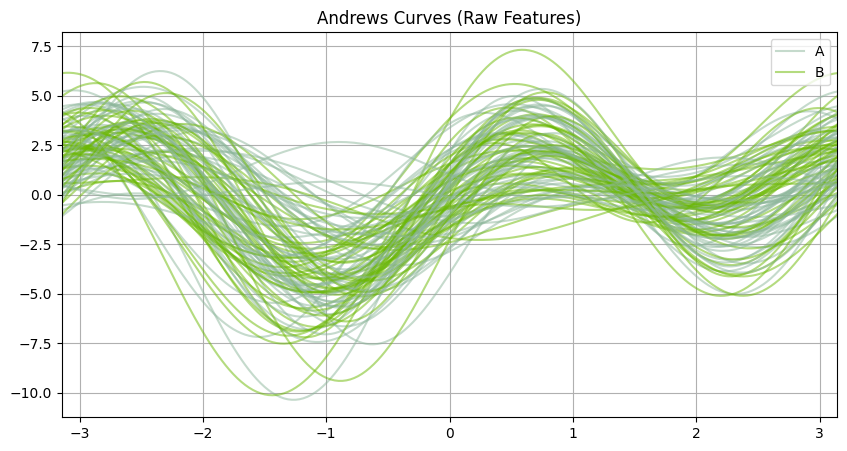

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import andrews_curves

# Sample data
np.random.seed(42)
df = pd.DataFrame({
    "F1": np.random.normal(0, 1, 100),
    "F2": np.random.normal(1, 1.2, 100),
    "F3": np.random.normal(-1, 0.8, 100),
    "F4": np.random.normal(2, 1.5, 100),
    "Class": np.random.choice(["A", "B"], 100)
})

plt.figure(figsize=(10, 5))
andrews_curves(df, class_column="Class", alpha=0.5)
plt.title("Andrews Curves (Raw Features)")
plt.show()


## Andrews Curves with Standardization (Best Practice)

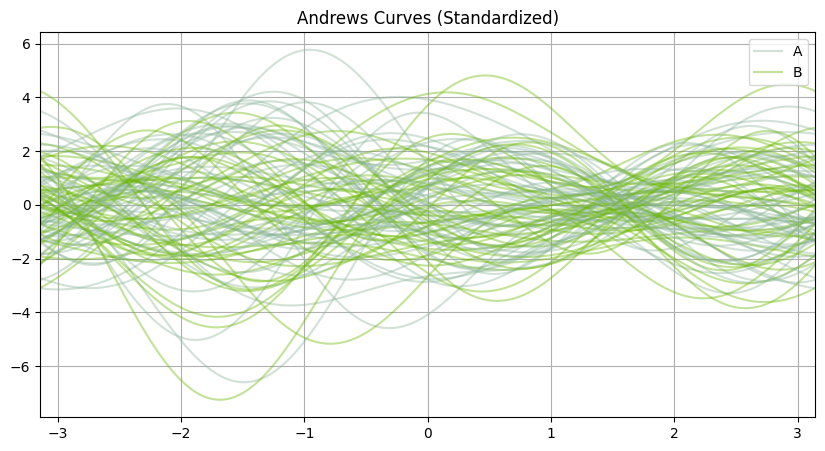

In [3]:
from sklearn.preprocessing import StandardScaler

features = df.drop(columns="Class")
scaled = StandardScaler().fit_transform(features)

df_scaled = pd.DataFrame(scaled, columns=features.columns)
df_scaled["Class"] = df["Class"]

plt.figure(figsize=(10, 5))
andrews_curves(df_scaled, "Class", alpha=0.4)
plt.title("Andrews Curves (Standardized)")
plt.show()


## Highlight One Class (Pattern Discovery)

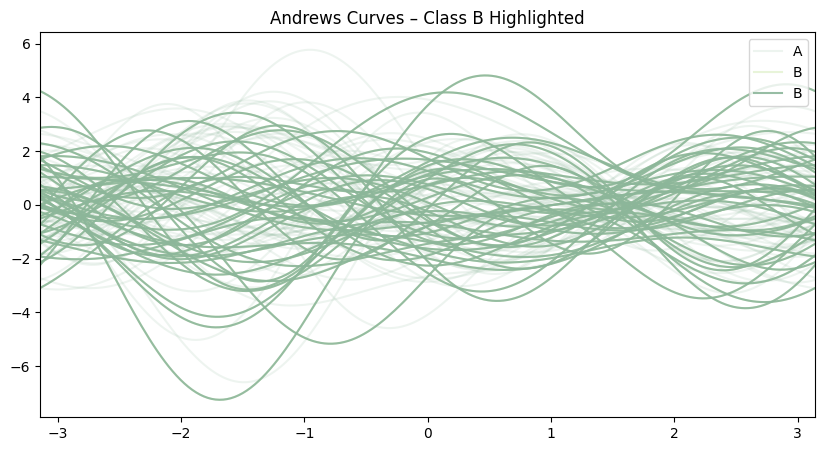

In [4]:
plt.figure(figsize=(10, 5))

# Plot all lightly
andrews_curves(df_scaled, "Class", alpha=0.15)

# Highlight Class B
df_B = df_scaled[df_scaled["Class"] == "B"]
andrews_curves(df_B, "Class", alpha=0.9)

plt.title("Andrews Curves – Class B Highlighted")
plt.show()


## Andrews Curves for Outlier Detection

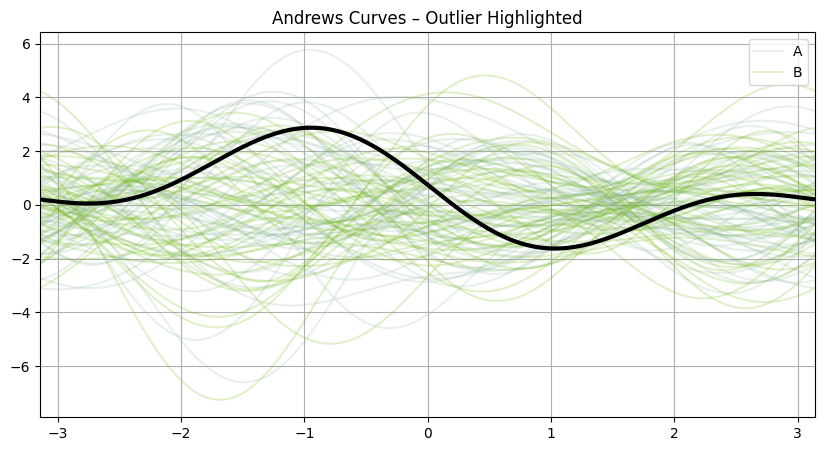

In [5]:
plt.figure(figsize=(10, 5))
andrews_curves(df_scaled, "Class", alpha=0.2)

# Highlight one extreme sample
row = df_scaled.iloc[0, :-1].values
t = np.linspace(-np.pi, np.pi, 200)

f = (row[0] / np.sqrt(2) +
     row[1] * np.sin(t) +
     row[2] * np.cos(t) +
     row[3] * np.sin(2 * t))

plt.plot(t, f, color="black", linewidth=3)
plt.title("Andrews Curves – Outlier Highlighted")
plt.show()


## Reduce Clutter (Sampling Strategy)

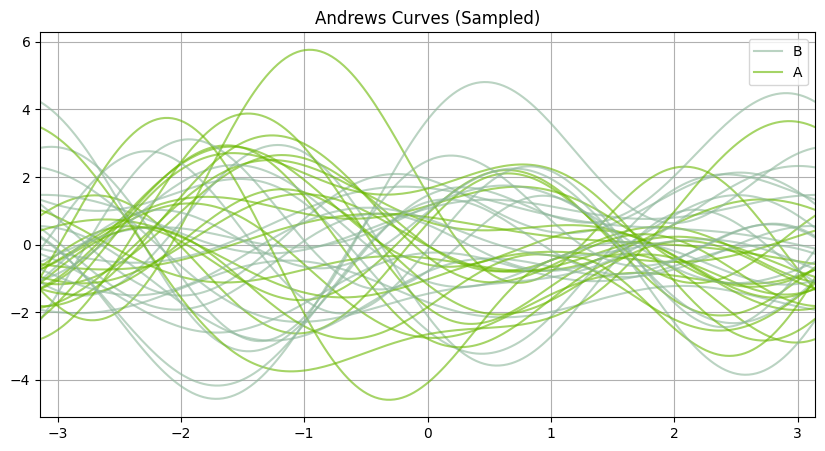

In [6]:
sampled_df = df_scaled.sample(40)

plt.figure(figsize=(10, 5))
andrews_curves(sampled_df, "Class", alpha=0.6)
plt.title("Andrews Curves (Sampled)")
plt.show()


## Andrews Curves for ML Diagnostics
🔹 Correct vs Incorrect Predictions

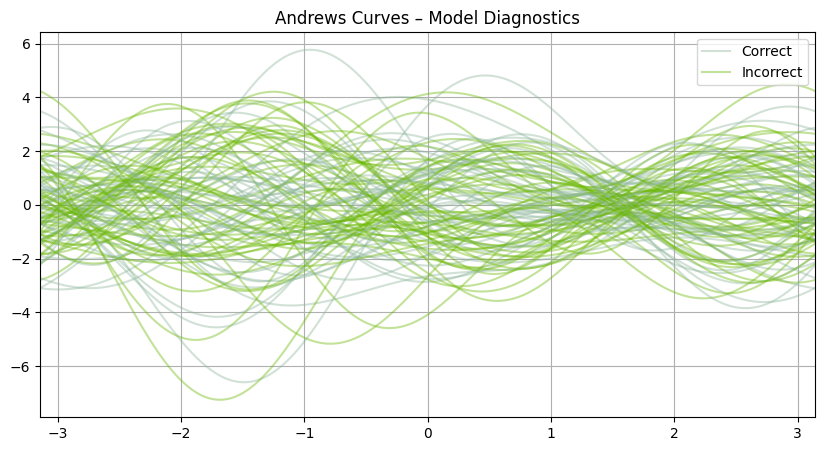

In [8]:
features = ["F1", "F2", "F3", "F4"]  # numeric only

df_andrews = df_ml[features + ["Prediction"]]

plt.figure(figsize=(10, 5))
andrews_curves(df_andrews, "Prediction", alpha=0.4)
plt.title("Andrews Curves – Model Diagnostics")
plt.show()
